# Basemap Plotting with pyramids

This notebook demonstrates how to add web tile basemaps (OpenStreetMap, CartoDB, Esri, etc.) underneath your raster and vector data plots.

**Requirements**: `pip install pyramids-gis[viz]` (installs mercantile, xyzservices, Pillow alongside cleopatra)

In [1]:
import matplotlib.pyplot as plt

from pyramids.basemap import add_basemap, get_provider
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

2026-07-13 01:31:20 | INFO | pyramids.base.config | Logging is configured.


## 1. Standalone `add_basemap()` on any matplotlib axes

The simplest usage: create a matplotlib plot with geographic coordinates, then call `add_basemap()` to add tiles behind your data.

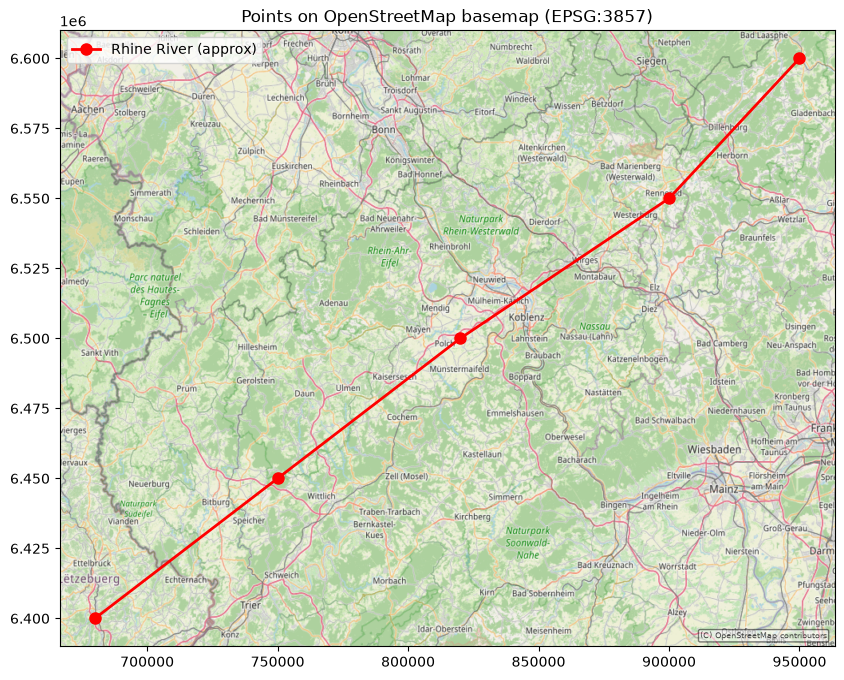

In [2]:
# Plot some points in EPSG:3857 (Web Mercator) and add a basemap
fig, ax = plt.subplots(figsize=(10, 8))

# Rhine river approximate coordinates in EPSG:3857
x = [680000, 750000, 820000, 900000, 950000]
y = [6400000, 6450000, 6500000, 6550000, 6600000]
ax.plot(x, y, "r-o", linewidth=2, markersize=8, label="Rhine River (approx)")
ax.legend()

# Add basemap -- data is in EPSG:3857, so no warping needed
add_basemap(ax, crs=3857)
plt.title("Points on OpenStreetMap basemap (EPSG:3857)")
plt.show()

## 2. Different tile providers

Use the `source` parameter to switch between tile providers. Pass a dot-separated name like `"CartoDB.Positron"` or `"Esri.WorldImagery"`.

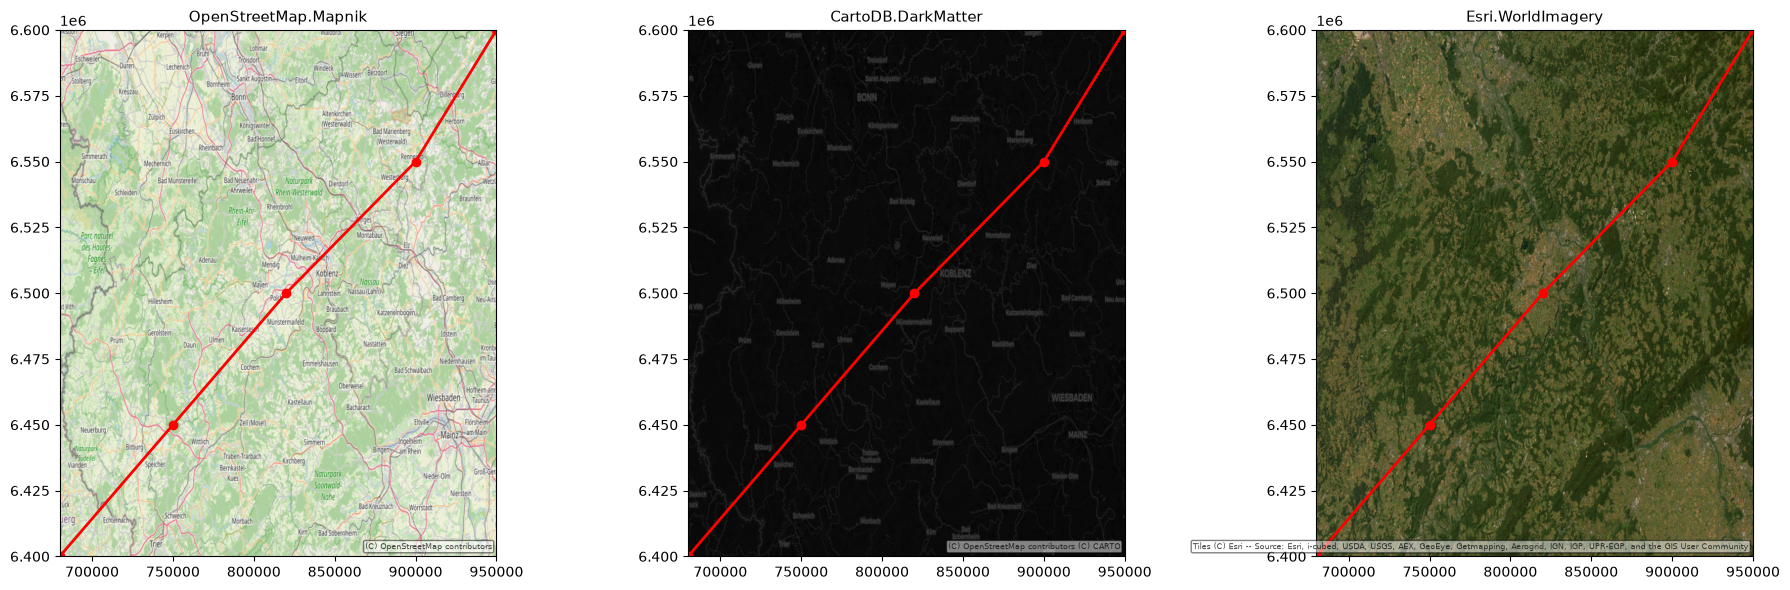

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

providers = ["OpenStreetMap.Mapnik", "CartoDB.DarkMatter", "Esri.WorldImagery"]

for ax, provider_name in zip(axes, providers):
    ax.set_xlim(680000, 950000)
    ax.set_ylim(6400000, 6600000)
    ax.plot(x, y, "r-o", linewidth=2, markersize=6)
    add_basemap(ax, crs=3857, source=provider_name)
    ax.set_title(provider_name, fontsize=11)

plt.tight_layout()
plt.show()

## 3. Data in EPSG:4326 (automatic CRS warping)

When your data is not in Web Mercator (EPSG:3857), `add_basemap()` automatically reprojects the tile image to match your data's CRS using GDAL.

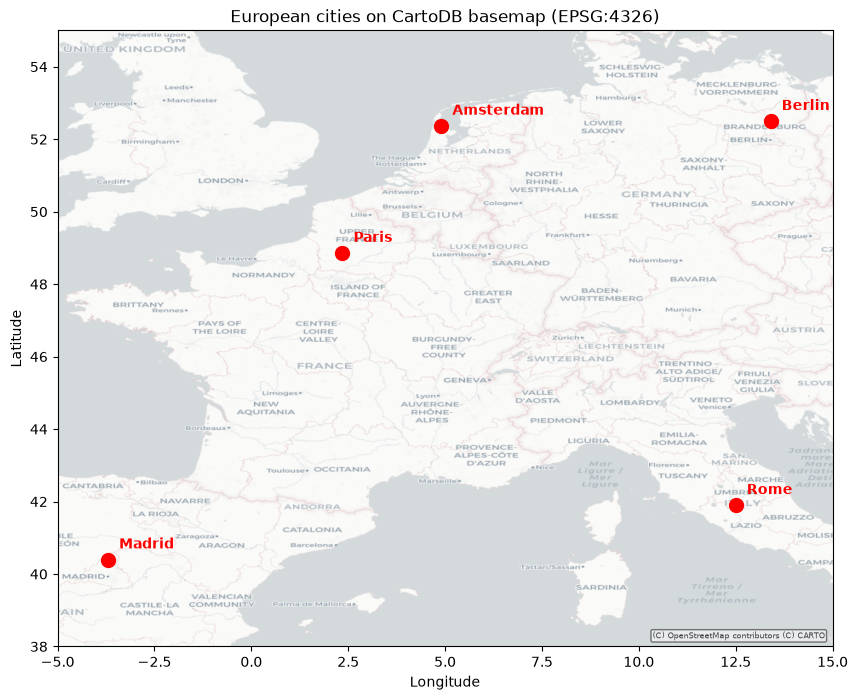

In [4]:
# Plot in EPSG:4326 (degrees) -- basemap tiles are warped from 3857 to 4326
fig, ax = plt.subplots(figsize=(10, 8))

# Some cities in Europe (lon, lat)
cities = {
    "Berlin": (13.4, 52.5),
    "Paris": (2.35, 48.86),
    "Rome": (12.5, 41.9),
    "Madrid": (-3.7, 40.4),
    "Amsterdam": (4.9, 52.37),
}

for name, (lon, lat) in cities.items():
    ax.plot(lon, lat, "ro", markersize=10)
    ax.annotate(
        name,
        (lon, lat),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=10,
        fontweight="bold",
        color="red",
    )

ax.set_xlim(-5, 15)
ax.set_ylim(38, 55)

# CRS=4326 triggers automatic warping of basemap tiles
add_basemap(ax, crs=4326, source="CartoDB.Positron")
plt.title("European cities on CartoDB basemap (EPSG:4326)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 4. Dataset.plot() with basemap parameter

The `basemap` parameter is integrated directly into `Dataset.plot()`. Pass `True` for default OpenStreetMap or a provider name string.

In [5]:
# Load a raster dataset (UTM projection, EPSG:32618)
ds = Dataset.read_file("../../../examples/data/geotiff/coello-without-color-table.tif")
print(f"CRS: EPSG:{ds.epsg}")
print(f"Shape: {ds.shape}")
print(f"BBox: {ds.bbox}")

CRS: EPSG:32618
Shape: (1, 13, 14)
BBox: [432968.1206170588, 468007.787999178, 488968.1206170588, 520007.787999178]


/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:816: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


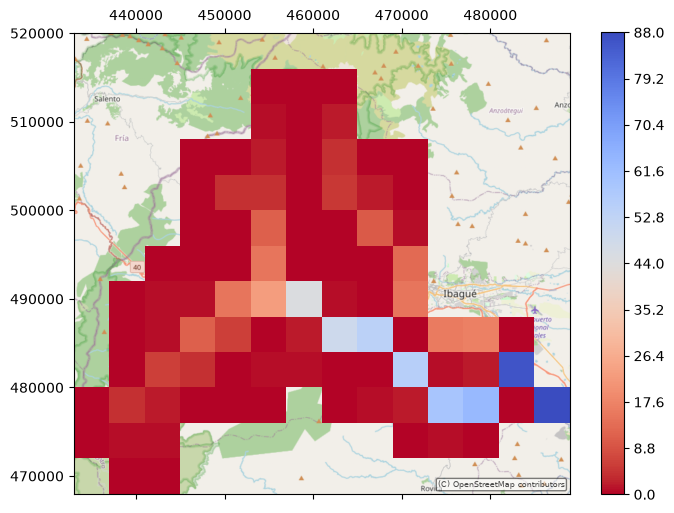

In [6]:
# Plot with default basemap (OpenStreetMap)
ds.plot(band=0, basemap=True)

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:816: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


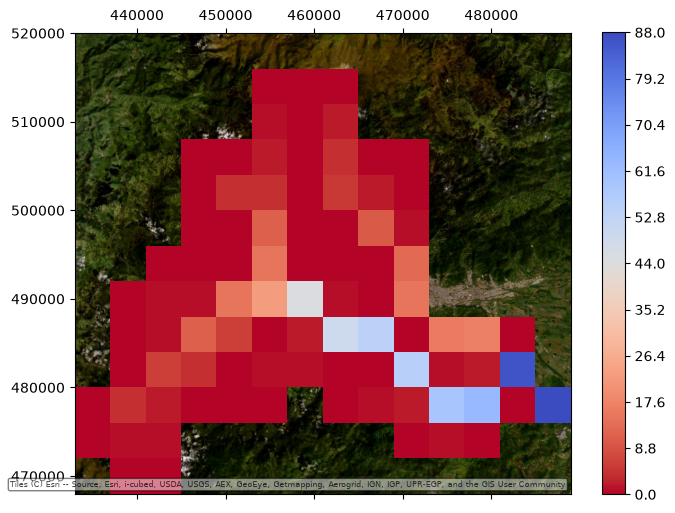

In [7]:
# Plot with satellite imagery basemap
ds.plot(band=0, basemap="Esri.WorldImagery")

## 5. FeatureCollection.plot() with basemap

Vector data can also be plotted on top of basemaps using `FeatureCollection.plot()`.

In [8]:
# Load vector data (gauge stations in UTM)
fc = FeatureCollection.read_file("../../../examples/data/coello-gauges.geojson")
print(f"CRS: EPSG:{fc.epsg}")
print(f"Bounds: {fc.total_bounds}")
print(f"Features: {len(fc)}")

CRS: EPSG:32618
Bounds: [443847.5736 478045.572  487292.5152 503143.3264]
Features: 6


<Axes: >

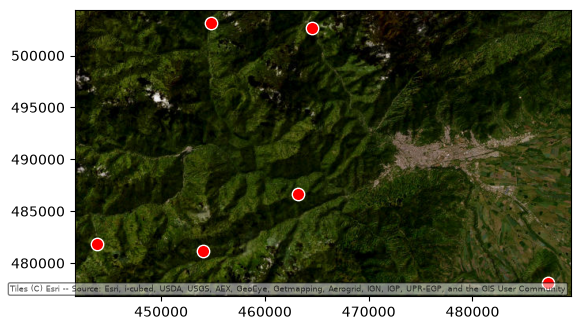

In [9]:
# Plot gauge stations on a satellite basemap
fc.plot(basemap="Esri.WorldImagery", markersize=80, color="red", edgecolor="white")

## 6. Standalone add_basemap() with a Dataset plot (two-step workflow)

You can also call `add_basemap()` separately after any plot. This gives you more control over parameters like `alpha`, `zorder`, and `zoom`.

<Axes: >

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:816: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


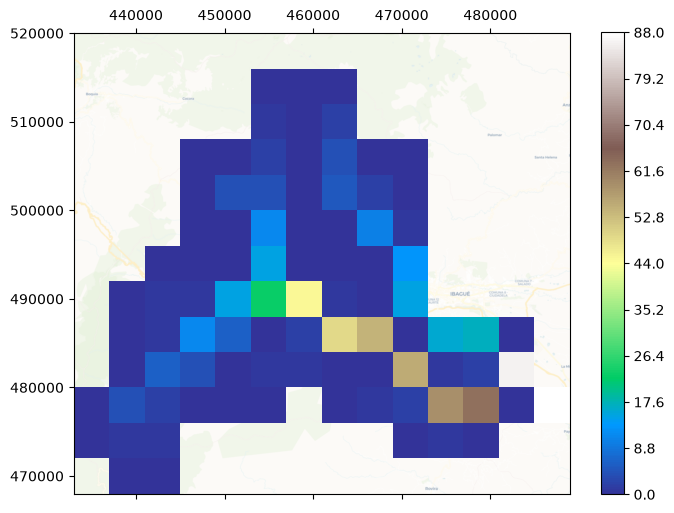

In [10]:
# Two-step workflow: plot first, then add basemap with custom settings
glyph = ds.plot(band=0, cmap="terrain")

add_basemap(
    glyph.ax,
    crs=ds.epsg,
    source="CartoDB.Voyager",
    alpha=0.6,  # semi-transparent basemap
    zoom=12,  # explicit zoom level
    attribution=False,  # hide attribution text
)

## 7. List available tile providers

Use `get_provider()` to resolve provider names, or explore the `xyzservices` catalog directly.

In [11]:
# Get a specific provider
provider = get_provider("CartoDB.Positron")
print(f"Name: {provider.name}")
print(f"URL: {provider.url}")
print(f"Attribution: {provider.attribution}")

# List all top-level provider groups
import xyzservices.providers as xyz

print(f"\nAvailable provider groups: {list(xyz.keys())}")

Name: CartoDB.Positron
URL: https://{s}.basemaps.cartocdn.com/{variant}/{z}/{x}/{y}{r}.png
Attribution: (C) OpenStreetMap contributors (C) CARTO

Available provider groups: ['OpenStreetMap', 'MapTilesAPI', 'OpenSeaMap', 'OPNVKarte', 'OpenTopoMap', 'OpenRailwayMap', 'OpenFireMap', 'SafeCast', 'Stadia', 'Thunderforest', 'BaseMapDE', 'CyclOSM', 'Jawg', 'MapBox', 'MapTiler', 'TomTom', 'Esri', 'OpenWeatherMap', 'HERE', 'FreeMapSK', 'MtbMap', 'CartoDB', 'HikeBike', 'BasemapAT', 'nlmaps', 'NASAGIBS', 'NLS', 'JusticeMap', 'GeoportailFrance', 'OneMapSG', 'USGS', 'WaymarkedTrails', 'OpenAIP', 'OpenSnowMap', 'AzureMaps', 'SwissFederalGeoportal', 'TopPlusOpen', 'Gaode', 'Strava', 'OrdnanceSurvey', 'UN']


## 8. Combining raster and vector on the same basemap

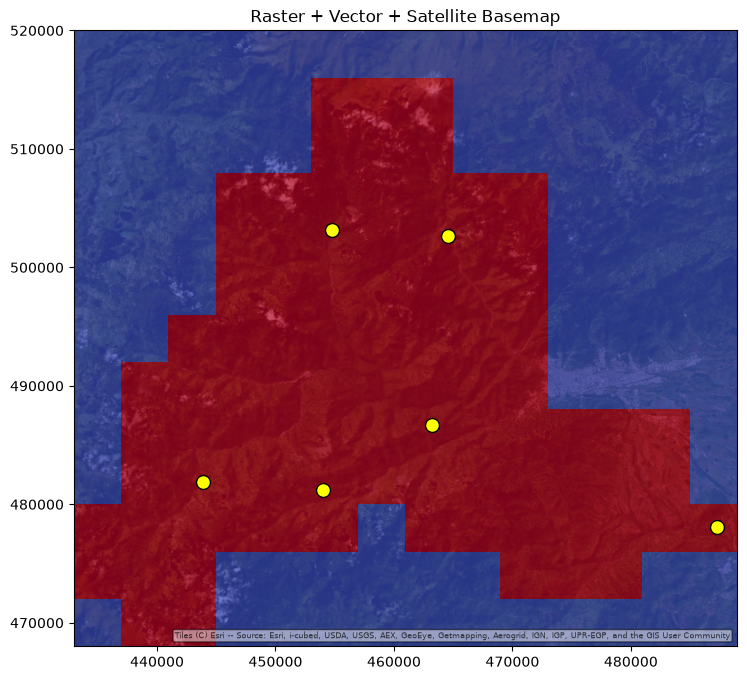

In [12]:
# Plot raster with semi-transparent overlay, then add vector points and basemap
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the raster
arr = ds.read_array(band=0)
ax.imshow(
    arr,
    extent=[ds.bbox[0], ds.bbox[2], ds.bbox[1], ds.bbox[3]],
    cmap="coolwarm",
    alpha=0.7,
    zorder=1,
)

# Overlay gauge stations
fc.plot(ax=ax, color="yellow", edgecolor="black", markersize=100, zorder=2)

# Add basemap underneath everything
add_basemap(ax, crs=ds.epsg, source="Esri.WorldImagery")

plt.title("Raster + Vector + Satellite Basemap")
plt.show()